## Build a Basic Chatbot with Langgraph ( Graph API )

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
    
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    messages : Annotated[list,add_messages] 

graph_builder =  StateGraph[State]

In [4]:
graph_builder

langgraph.graph.state.StateGraph[__main__.State]

In [5]:
import os 
from dotenv import load_dotenv
load_dotenv()


True

In [6]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model = "openai/gpt-oss-20b")

In [7]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000185743B10F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000185743B1000>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [9]:
graph_builder = StateGraph(State)

graph_builder.add_node("llmchatbot",chatbot) # Adding node 

graph_builder.add_edge(START, "llmchatbot") # Adding Edge from start to llmchatbot
graph_builder.add_edge("llmchatbot",END) # Adding Edge from llmchatbot to end

graph = graph_builder.compile() # Compiling the graph

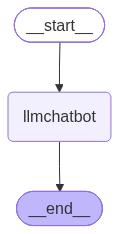

In [10]:
# Visualizing the graph

from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
response = graph.invoke({"messages":"Hi"})

In [12]:
response["messages"][-1].content

'Hello! How can I help you today?'

# Chatbot With Tools 

In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is Langgraph?")

{'query': 'what is Langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian C

In [14]:
def multiply(a: int, b: int) -> int:
    """Multiply two integers"""
    return a * b

In [15]:
tools = [tool, multiply]

In [16]:
llm_with_tools = llm.bind_tools(tools)

In [17]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000185743B10F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000185743B1000>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': '

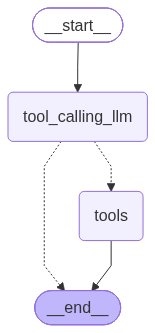

In [18]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If latest message from assistant is tool call, then go to tools node 
    # If latest message from assistant is not tool call, then go to end node
    tools_condition
)
builder.add_edge("tools",END)

# Compile the graph
graph = builder.compile()

from IPython.display import display,Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
response = graph.invoke({"messages":"what is Langgraph?"})

In [20]:
response['messages'][-1].content

'**LangGraph** is a framework (and ecosystem of tools) built on top of **LangChain** that lets developers design, orchestrate, and execute *state‑driven* workflows for large‑language‑model (LLM) applications.  \nIt turns the idea of a “conversation” or “task” into an explicit graph of nodes, each node being a small, reusable piece of logic (e.g., a prompt, a call to an external API, a decision step, or a data‑processing routine).  \n\nBelow is a quick‑start guide that covers the key concepts, why it’s useful, and how you can get started.\n\n---\n\n## 1. Core Concepts\n\n| Concept | What it is | Why it matters |\n|---------|------------|----------------|\n| **Node** | A single unit of computation (prompt, LLM call, API call, logic). | Keeps code modular and testable. |\n| **Edge** | Directed connection between nodes that can carry state or a conditional trigger. | Enables branching, loops, and parallelism. |\n| **Graph** | The entire network of nodes and edges that defines the workflow.

In [21]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is Langgraph?
================================== Ai Message ==================================

**LangGraph** is a framework (and ecosystem of tools) built on top of **LangChain** that lets developers design, orchestrate, and execute *state‑driven* workflows for large‑language‑model (LLM) applications.  
It turns the idea of a “conversation” or “task” into an explicit graph of nodes, each node being a small, reusable piece of logic (e.g., a prompt, a call to an external API, a decision step, or a data‑processing routine).  

Below is a quick‑start guide that covers the key concepts, why it’s useful, and how you can get started.

---

## 1. Core Concepts

| Concept | What it is | Why it matters |
|---------|------------|----------------|
| **Node** | A single unit of computation (prompt, LLM call, API call, logic). | Keeps code modular and testable. |
| **Edge** | Directed connection between nodes tha

In [22]:
response = graph.invoke({"messages":"what is 2 multiplied by 6?"})

In [23]:
response['messages'][-1].content

'2 multiplied by 6 equals **12**.'

In [24]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 6?
================================== Ai Message ==================================

2 multiplied by 6 equals **12**.


# Adding Memory in Agentic Graph

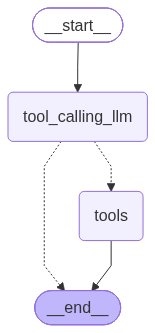

In [25]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If latest message from assistant is tool call, then go to tools node 
    # If latest message from assistant is not tool call, then go to end node
    tools_condition
)
builder.add_edge("tools",END)

# Compile the graph
graph = builder.compile(checkpointer = memory)

from IPython.display import display,Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
config = {"configurable": {"thread_id": "1"}}

In [27]:
response = graph.invoke({"messages":"Hi my name is Arnav"},config = config)
response

{'messages': [HumanMessage(content='Hi my name is Arnav', additional_kwargs={}, response_metadata={}, id='3c4824a9-aa97-44be-9f3b-f6eeb7f8a556'),
  AIMessage(content='Hello Arnav! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We have a conversation: user says "Hi my name is Arnav". We need to respond. It\'s a greeting. We can respond warmly, ask how we can help. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 341, 'total_tokens': 403, 'completion_time': 0.064886839, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.019150829, 'prompt_tokens_details': None, 'queue_time': 0.331033247, 'total_time': 0.084037668}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_84bb35977d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09a32-3ce7-7943-ac19-c90ef3ef1dc0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input

In [28]:
response['messages'][-1].content

'Hello Arnav! 👋 How can I help you today?'

In [29]:
response = graph.invoke({"messages":"What is my name?"},config = config)
print(response['messages'][-1].content)

Your name is Arnav.


# Streaming


In [30]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [31]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

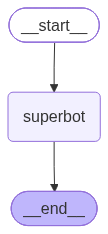

In [33]:
graph = StateGraph(State)

graph.add_node("superbot",superbot)

graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

graph_builder = graph.compile(checkpointer = memory)

from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [34]:
config = {"configurable": {"thread_id": "1"}}
graph_builder.invoke({"messages":"Hi my name is Arnav"},config = config)

{'messages': [HumanMessage(content='Hi my name is Arnav', additional_kwargs={}, response_metadata={}, id='8da67a15-afba-49c6-8473-254e629a9020'),
  AIMessage(content='Hello Arnav! 👋 How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says: "Hi my name is Arnav". We need to respond. The user might want a greeting, maybe ask about them. There\'s no specific question. So we respond politely, ask how we can help.'}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 77, 'total_tokens': 145, 'completion_time': 0.068799626, 'completion_tokens_details': {'reasoning_tokens': 46}, 'prompt_time': 0.004291865, 'prompt_tokens_details': None, 'queue_time': 0.344609331, 'total_time': 0.073091491}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_2b688e7cc3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09a35-156c-7131-be3f-1b4ae48e1882-0', tool_calls=[], invalid_too